In [1]:
from hea.R import *
from hea.plot import *
from hea import data, col, lm, lme

### 1.2.1

In [2]:
Dyestuff = data("Dyestuff")
head(Dyestuff)

Batch,Yield
enum,i64
"""A""",1545
"""A""",1440
"""A""",1440
"""A""",1520
"""A""",1580
"""B""",1540


In [3]:
summary(Dyestuff)

Batch     Yield
A:5    Min.   :1440
B:5    1st Qu.:1469
C:5    Median :1530
D:5    Mean   :1528
E:5    3rd Qu.:1575
F:5    Max.   :1635

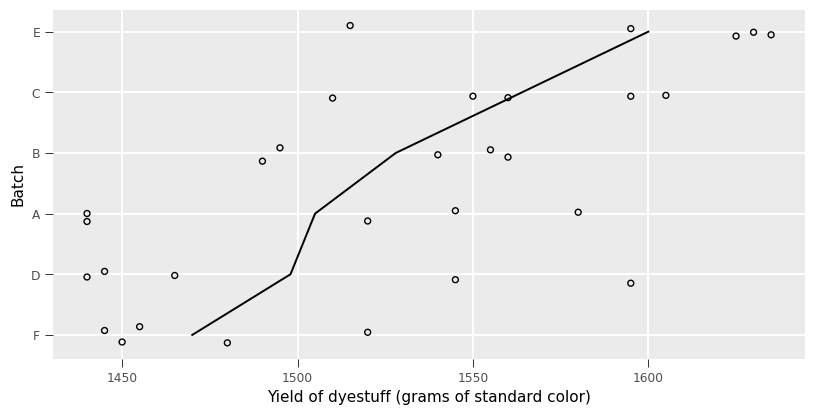

In [ ]:
from hea import fct_reorder

dye_ord = Dyestuff.mutate(Batch=fct_reorder("Batch", "Yield"))

(
    dye_ord
        .ggplot(x="Yield", y="Batch")
        .geom_jitter(height=0.15, width=0, shape=1)
        .stat_summary(geom='line', fun='mean', group=1)
        .labs(x="Yield of dyestuff (grams of standard color)", y="Batch")
).show(figsize=(8, 4))


### 1.2.2

In [12]:
Dyestuff2 = data("Dyestuff2")
summary(Dyestuff2)

Batch       Yield
A:5    Min.   :-0.8920
B:5    1st Qu.: 2.7650
C:5    Median : 5.3650
D:5    Mean   : 5.6656
E:5    3rd Qu.: 8.1510
F:5    Max.   :13.4340

### 1.3.1

In [13]:
fm01 = lme("Yield ~ 1 + (1 | Batch)", Dyestuff)
summary(fm01)

Linear mixed model fit by REML
Formula: Yield ~ 1 + (1 | Batch)

REML criterion at convergence: 319.6543

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4117 -0.7634 0.1418 0.7792 1.8296

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 1764     42.00
 Residual             2451     49.51
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   1527.50       19.38    78.80


In [ ]:
summary(fm01ML := lme("Yield ~ 1 + (1 | Batch)", Dyestuff, REML=False))

Linear mixed model fit by maximum likelihood
Formula: Yield ~ 1 + (1 | Batch)

     AIC      BIC    logLik -2*log(L) df.resid
333.3271 337.5307 -163.6635  327.3271       27

Scaled residuals:
    Min      1Q Median     3Q    Max
-1.4315 -0.7972 0.1480 0.7721 1.8037

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 1388     37.26
 Residual             2451     49.51
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   1527.50       17.69    86.33


In [ ]:
summary(fm02 := lme("Yield ~ 1 + (1 | Batch)", Dyestuff2))

Linear mixed model fit by REML
Formula: Yield ~ 1 + (1 | Batch)

REML criterion at convergence: 161.8283

Scaled residuals:
    Min      1Q  Median     3Q    Max
-1.7648 -0.7806 -0.0809 0.6689 2.0907

Random effects:
 Groups   Name        Variance Std.Dev.
 Batch    (Intercept) 0.00     0.000
 Residual             13.81    3.716
Number of obs: 30, groups:  Batch, 6

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)    5.6656      0.6784    8.352
